# Notebook para practicas
---

## 1. Definición de variables | librerias && funciones utiles de uso recursivas

### 1.1 Librerias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures

### 1.2 Constantes

In [26]:
PATH_DIRECTORIO_DATOS = "../../data/raw"

# PATH_DATASET_ADVERTISING = f"{PATH_DIRECTORIO_DATOS}/advertising.csv"
# PATH_DATASET_CALORIES = f"{PATH_DIRECTORIO_DATOS}/calories.csv"
# PATH_DATASET_CALORIES_LITE = f"{PATH_DIRECTORIO_DATOS}/calories_time_reduc.csv"
# PATH_DATASET_CALORIES_TIME = f"{PATH_DIRECTORIO_DATOS}/calories_time.csv"
# PATH_DATASET_HEART = f"{PATH_DIRECTORIO_DATOS}/heart_disease.csv"
# PATH_DATASET_BOSTON = f"{PATH_DIRECTORIO_DATOS}/housing_boston.csv"
# PATH_DATASET_TWEETS = f"{PATH_DIRECTORIO_DATOS}/nlp_tweets.csv"
PATH_DATASET_RESERVAS = f"{PATH_DIRECTORIO_DATOS}/dataset_practica_final.csv"

### 1.3 Funciones

In [9]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

def plot_regresion_lineal_interactiva(df: pd.DataFrame, variable_independiente: str, variable_dependiente: str, modelo: LinearRegression, titulo: str = "Regresión Lineal", xaxis_titulo: str = "X", yaxis_titulo: str = "Y") -> go.Figure:
    """Genera un gráfico interactivo de regresión lineal usando Plotly.
    
    Crea una visualización interactiva que muestra los datos originales como puntos y la línea
    de regresión lineal ajustada. También muestra la ecuación del modelo y las métricas de evaluación
    (MSE, RMSE, MAE, R²) en anotaciones sobre el gráfico.
    
    Args:
        df (pd.DataFrame): DataFrame que contiene los datos para visualizar.
        variable_independiente (str): Nombre de la columna con la variable independiente (X).
        variable_dependiente (str): Nombre de la columna con la variable dependiente (Y).
        modelo (LinearRegression): Modelo de regresión lineal previamente entrenado.
        titulo (str, optional): Título del gráfico. Por defecto es "Regresión Lineal".
        xaxis_titulo (str, optional): Título del eje X. Por defecto es "X".
        yaxis_titulo (str, optional): Título del eje Y. Por defecto es "Y".
    
    Returns:
        go.Figure: Objeto Figure de Plotly que puede ser mostrado con .show() o 
                   incluido en un dashboard.
    
    Example:
        >>> modelo = LinearRegression()
        >>> modelo.fit(df[["tiempo"]], df["ventas"])
        >>> fig = plot_regresion_lineal_interactiva(
        ...     df, 
        ...     variable_independiente="tiempo",
        ...     variable_dependiente="ventas",
        ...     modelo=modelo,
        ...     titulo="Ventas vs Tiempo",
        ...     xaxis_titulo="Tiempo (días)",
        ...     yaxis_titulo="Ventas ($)"
        ... )
        >>> fig.show()
    """
    
    # Calcular las métricas de evaluación
    X = df[[variable_independiente]]
    y = df[variable_dependiente]
    
    y_pred = modelo.predict(X)
    mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y, verbose=False)

    # Crear la figura
    fig = go.Figure()

    # Añadir los puntos de datos
    fig.add_trace(
        go.Scatter(
            x=df[variable_independiente], 
            y=df[variable_dependiente],
            mode='markers',
            name='Datos reales',
            marker=dict(color='blue', size=8, opacity=0.6)
        )
    )

    # Añadir la línea de regresión
    fig.add_trace(
        go.Scatter(
            x=df[variable_independiente], 
            y=y_pred,
            mode='lines',
            name='Regresión lineal',
            line=dict(color='red', width=2)
        )
    )

    # Coeficientes del modelo
    coeficiente = modelo.coef_[0]
    intercepto = modelo.intercept_

    # Ecuación y métricas para mostrar en el gráfico
    equation_text = f"Ecuación: y = {coeficiente:.4f} × x + {intercepto:.4f}"
    metrics_text = f"MSE: {mse:.2f}, RMSE: {rmse:.2f}<br>MAE: {mae:.2f}, R²: {r2:.4f}"

    # Añadir anotaciones
    fig.add_annotation(
        x=0.02,
        y=0.98,
        xref="paper",
        yref="paper",
        text=equation_text,
        showarrow=False,
        font=dict(size=14),
        align="left",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )

    fig.add_annotation(
        x=0.02,
        y=0.90,
        xref="paper",
        yref="paper",
        text=metrics_text,
        showarrow=False,
        font=dict(size=12),
        align="left",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1
    )

    # Configuración del diseño
    fig.update_layout(
        title=titulo,
        xaxis_title=xaxis_titulo,
        yaxis_title=yaxis_titulo,
        legend=dict(x=0.02, y=0.02),
        plot_bgcolor='white',
        width=900,
        height=600
    )

    # Añadir cuadrícula
    fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='lightgray')

    return fig

In [10]:
def plot_residuos(y_pred: np.ndarray, y_true: np.ndarray):
    """Genera un gráfico de dispersión de los residuos vs valores predichos.
    
    Este gráfico permite identificar patrones no aleatorios en los residuos que podrían
    indicar problemas con el modelo como heteroscedasticidad o no linealidad.
    
    Args:
        y_pred (np.ndarray): Valores predichos por el modelo.
        y_true (np.ndarray): Valores reales observados.
    
    Returns:
        None: Muestra el gráfico directamente.
    
    Example:
        >>> plot_residuos(model.predict(X), y)
    """    
    residuos = y_true - y_pred

    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuos, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.xlabel('Valores predichos')
    plt.ylabel('Residuos')
    plt.title('Residuos vs. Valores Predichos')
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_histograma_residuos(y_pred: np.ndarray, y_true: np.ndarray):
    """Genera un histograma de los residuos del modelo.
    
    Permite evaluar la distribución de los residuos, idealmente debería
    aproximarse a una distribución normal centrada en cero.
    
    Args:
        y_pred (np.ndarray): Valores predichos por el modelo.
        y_true (np.ndarray): Valores reales observados.
    
    Returns:
        None: Muestra el gráfico directamente.
    
    Example:
        >>> plot_histograma_residuos(model.predict(X), y)
    """
    residuos = y_true - y_pred

    plt.figure(figsize=(10, 6))
    plt.hist(residuos, bins=15, alpha=0.7, color='blue', edgecolor='black')
    plt.axvline(x=0, color='r', linestyle='-')
    plt.xlabel('Residuos')
    plt.ylabel('Frecuencia')
    plt.title('Distribución de Residuos')
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_qq_plot_residuos(y_pred: np.ndarray, y_true: np.ndarray):
    """Genera un gráfico Q-Q (quantile-quantile) para evaluar la normalidad de los residuos.
    
    Compara los cuantiles de los residuos con los cuantiles teóricos de una
    distribución normal. Si los puntos siguen aproximadamente la línea diagonal,
    sugiere que los residuos siguen una distribución normal.
    
    Args:
        y_pred (np.ndarray): Valores predichos por el modelo.
        y_true (np.ndarray): Valores reales observados.
    
    Returns:
        None: Muestra el gráfico directamente.
    
    Example:
        >>> plot_qq_plot_residuos(model.predict(X), y)
    """
    residuos = y_true - y_pred
    plt.figure(figsize=(10, 6))
    stats.probplot(residuos, dist="norm", plot=plt)
    plt.title('Q-Q Plot de Residuos')
    plt.grid(True, alpha=0.3)
    plt.show()


def resumen_estadistico_residuos(y_pred: np.ndarray, y_true: np.ndarray, verbose=True) -> dict:
    """Calcula estadísticas descriptivas de los residuos del modelo.
    
    Genera un resumen estadístico con métricas básicas como media, desviación estándar,
    valores mínimo y máximo de los residuos.
    
    Args:
        y_pred (np.ndarray): Valores predichos por el modelo.
        y_true (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las estadísticas. Por defecto es True.
    
    Returns:
        dict: Diccionario con las estadísticas calculadas:
            - 'media': Media aritmética de los residuos.
            - 'desviacion_estandar': Desviación estándar de los residuos.
            - 'minimo': Valor mínimo de los residuos.
            - 'maximo': Valor máximo de los residuos.
    
    Example:
        >>> stats = resumen_estadistico_residuos(model.predict(X), y)
        >>> print(f"Desviación estándar: {stats['desviacion_estandar']:.4f}")
    """
    residuos = y_true - y_pred
    resumen = {
        'media': residuos.mean(),
        'desviacion_estandar': residuos.std(),
        'minimo': residuos.min(),
        'maximo': residuos.max()
    }
    if verbose:
        print("Resumen estadístico de los residuos:")
        print(f"Media: {resumen['media']:.4f}")
        print(f"Desviación estándar: {resumen['desviacion_estandar']:.4f}")
        print(f"Mínimo: {resumen['minimo']:.4f}")
        print(f"Máximo: {resumen['maximo']:.4f}")
    return resumen

In [11]:
def plot_matriz_correlacion(df: pd.DataFrame, variable_dependiente:str):
    """Genera una matriz de correlación interactiva utilizando Plotly.
    
    Crea una visualización de mapa de calor que muestra las correlaciones entre todas
    las variables numéricas del DataFrame, con anotaciones de los valores exactos.
    Adicionalmente, imprime un ranking de correlaciones con la variable dependiente
    especificada.
    
    Args:
        df (pd.DataFrame): DataFrame que contiene las variables numéricas para analizar.
        variable_dependiente (str): Nombre de la columna que se considera la variable dependiente,
                                   cuyas correlaciones se mostrarán ordenadas.
    
    Returns:
        None: Muestra el gráfico interactivo con Plotly y una tabla de correlaciones
              con la variable dependiente en la consola.
    
    Example:
        >>> plot_matriz_correlacion(df_calories, "calories")
    """
    
    # Crear matriz de correlación para visualizar relaciones entre variables con Plotly
    correlation_matrix = df.corr()

    # Crear un mapa de calor interactivo con Plotly
    fig = px.imshow(
        correlation_matrix,
        text_auto='.2f',                    # Mostrar valores numéricos con 2 decimales
        color_continuous_scale='RdBu_r',    # Esquema de colores (rojo-blanco-azul invertido)
        zmin=-1, zmax=1,                    # Rango de valores
        aspect="auto",                      # Ajustar aspecto automáticamente
        title='Matriz de Correlación entre Variables'
    )

    # Mejorar el diseño
    fig.update_layout(
        width=800, 
        height=700,
        coloraxis_colorbar=dict(
            title="Coeficiente<br>de Correlación",
            thicknessmode="pixels", thickness=20,
            lenmode="pixels", len=500,
            yanchor="top", y=1,
            ticks="outside"
        ),
        font=dict(size=12),
    )

    # Identificar y mostrar las correlaciones más fuertes con 'calories'
    correlaciones_con_calories = correlation_matrix[variable_dependiente].sort_values(ascending=False)

    # Mostrar el gráfico interactivo
    fig.show(renderer='iframe')

    # Imprimir correlaciones con 'calories'
    print(f"\nCorrelaciones con '{variable_dependiente}':")
    print(correlaciones_con_calories)

## 2. Lectura de datos:
---

In [27]:
df_reservas = pd.read_csv(PATH_DATASET_RESERVAS)

In [ ]:
# Mostrar las primeras líneas
df_reservas.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
#Mostrar las últimas filas
df_reservas.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [28]:
#Mostramos dimensiones del data frame (relación de filas por columnas).
df_reservas.shape

(119390, 32)

In [29]:
#Revisamos las columnas del data frame
df_reservas.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date']

In [30]:
#Mostrar información data frame
df_reservas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

### 2.2 Exploración de datos y estadisticas

In [31]:
#Descripción estadística de las columnas numéricas. Recomendación usar .transpose() para ver el listado de variables
df_reservas.transpose()

,0,1,2,3,4,5,6,7,8,9,...,119380,119381,119382,119383,119384,119385,119386,119387,119388,119389
hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,Resort Hotel,...,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel,City Hotel
is_canceled,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
lead_time,342,737,7,13,14,14,0,9,85,75,...,44,188,135,164,21,23,102,34,109,205
arrival_date_year,2015,2015,2015,2015,2015,2015,2015,2015,2015,2015,...,2017,2017,2017,2017,2017,2017,2017,2017,2017,2017
arrival_date_month,July,July,July,July,July,July,July,July,July,July,...,August,August,August,August,August,August,August,August,August,August
arrival_date_week_number,27,27,27,27,27,27,27,27,27,27,...,35,35,35,35,35,35,35,35,35,35
arrival_date_day_of_month,1,1,1,1,1,1,1,1,1,1,...,31,31,30,31,30,30,31,31,31,29
stays_in_weekend_nights,0,0,0,0,0,0,0,0,0,0,...,1,2,2,2,2,2,2,2,2,2
stays_in_week_nights,0,0,1,1,2,2,2,2,3,3,...,3,3,4,4,5,5,5,5,5,7
adults,2,2,1,1,2,2,2,2,2,2,...,2,2,3,2,2,2,3,2,2,2


In [32]:
df_reservas.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [33]:
df_reservas.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [34]:
#Setear los indices de las columnas a minusculas para no tener problemas a futuro
df_reservas.columns = df_reservas.columns.str.lower()

In [35]:
#Varificacióin de valores nulos
df_reservas.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [36]:
#Verificación valores duplicados
df_reservas.duplicated().sum()

31994

### 2.3 Visualización

<Axes: xlabel='adr', ylabel='Count'>

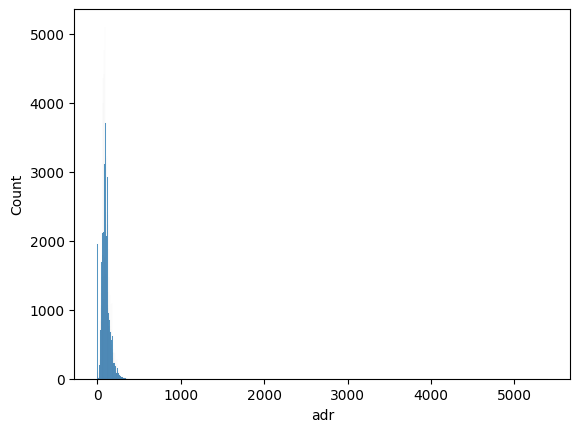

In [37]:
#Visualización de la distribución de variables usando seaborn
sns.histplot(df_reservas, x='adr')

<Axes: xlabel='adr', ylabel='Count'>

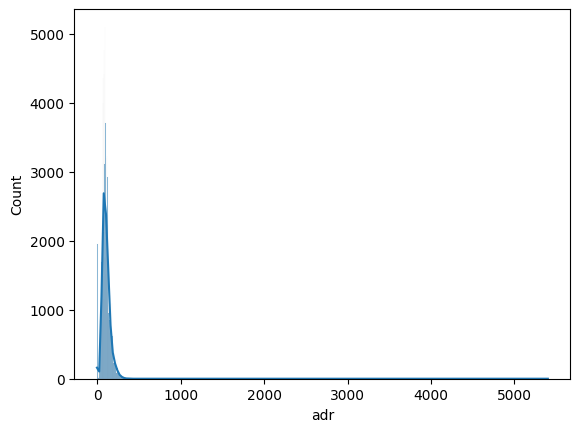

In [38]:
#Visualización de la distribución de variables usando seaborn con la función de densidad
sns.histplot(df_reservas, x='adr', kde=True)

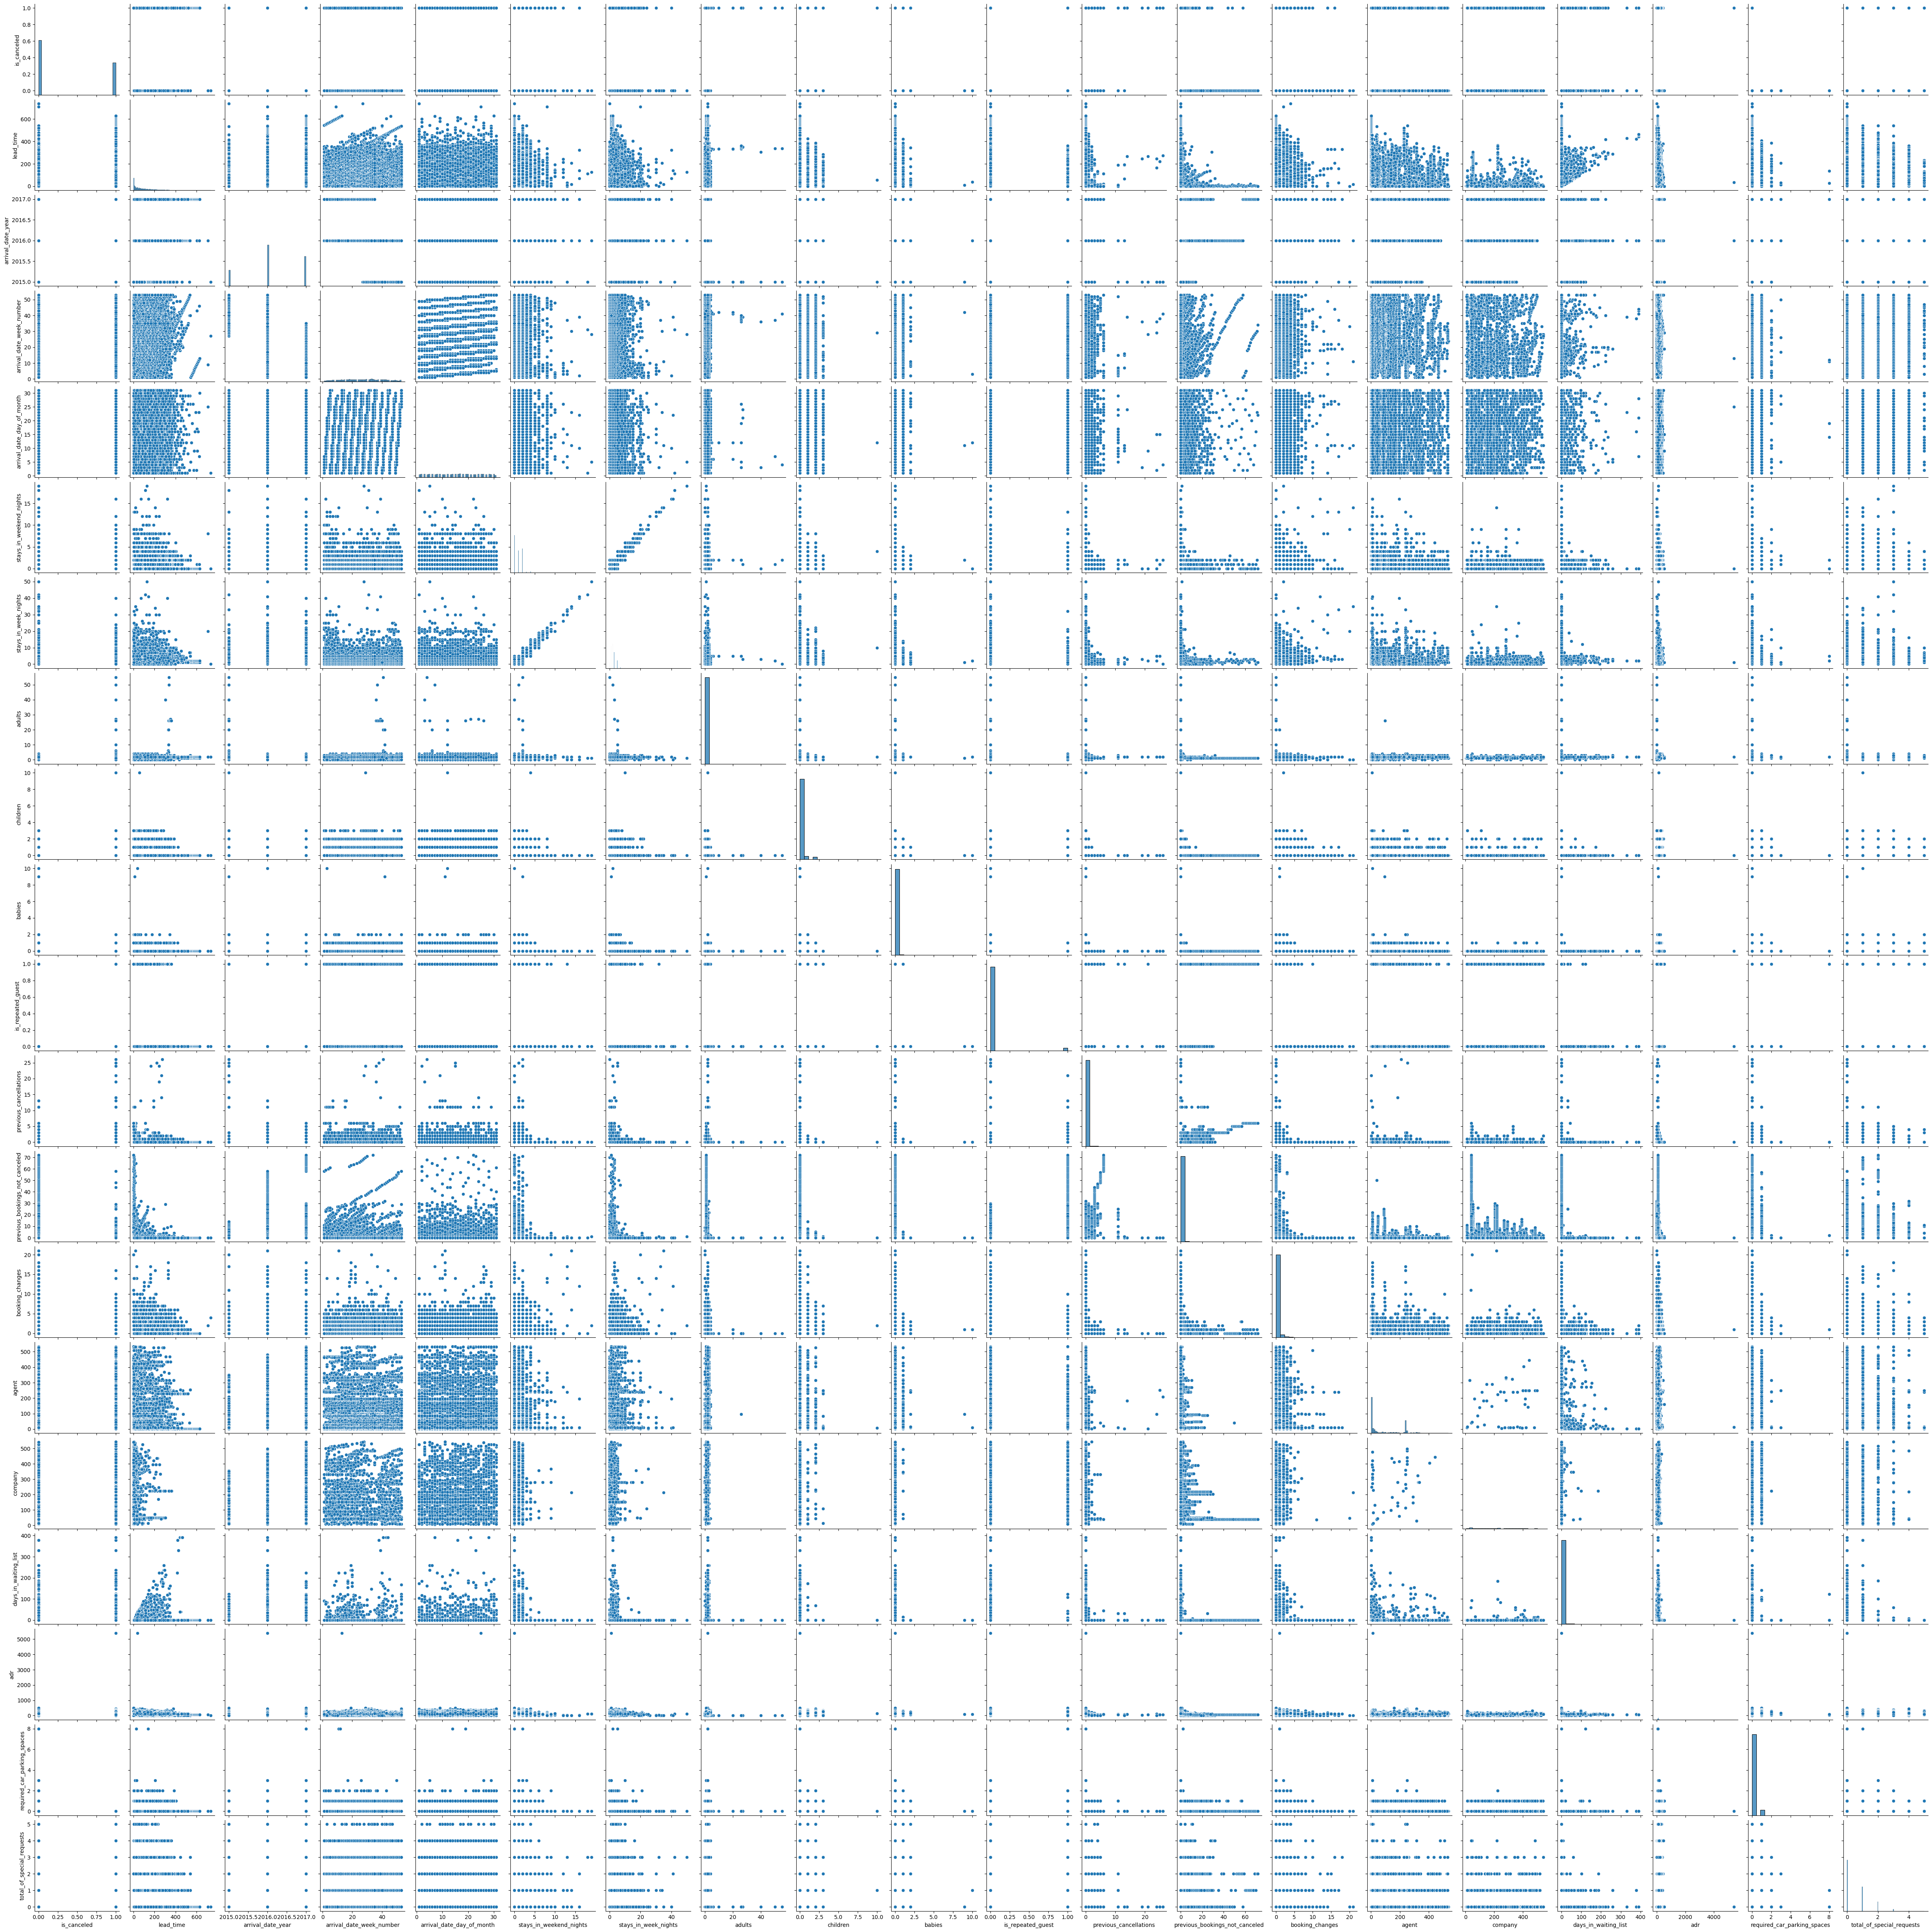

In [39]:
#Visualización de como se relacionan las variables
sns.pairplot(df_reservas)

In [40]:
# Porcentaje de nulos por columna
null_percent = (df_reservas.isnull().sum() / len(df_reservas)) * 100
null_percent[null_percent > 0].sort_values(ascending=False)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

Text(0.5, 1.0, 'Mapa de valores nulos')

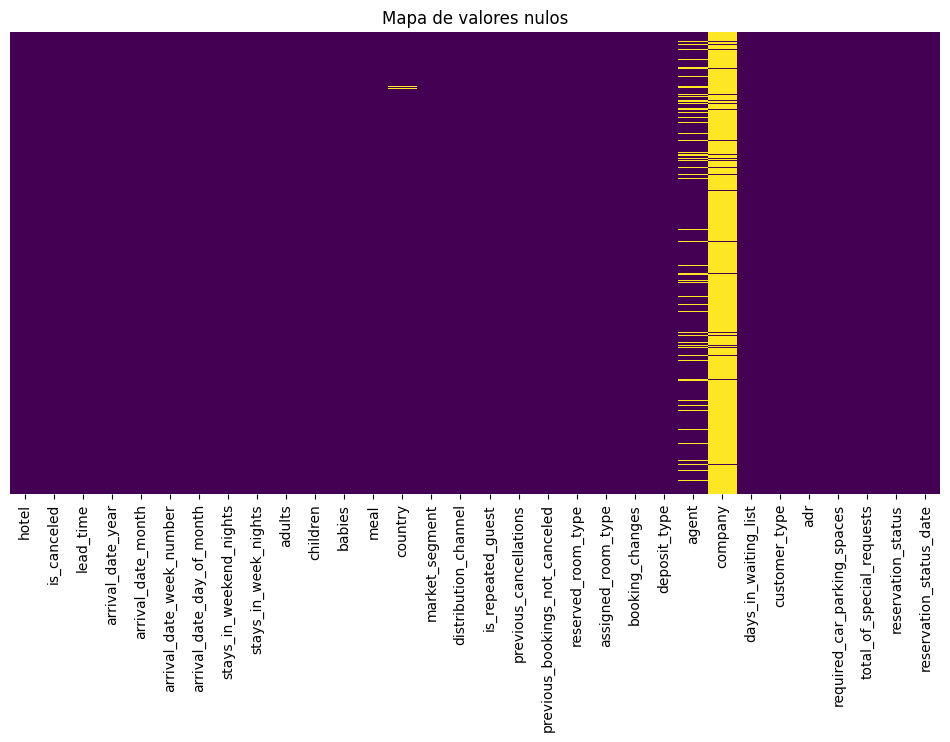

In [41]:
# Visualizar nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df_reservas.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de valores nulos')

Text(0.5, 1.0, 'Distribución de Cancelaciones (0=No, 1=Sí)')

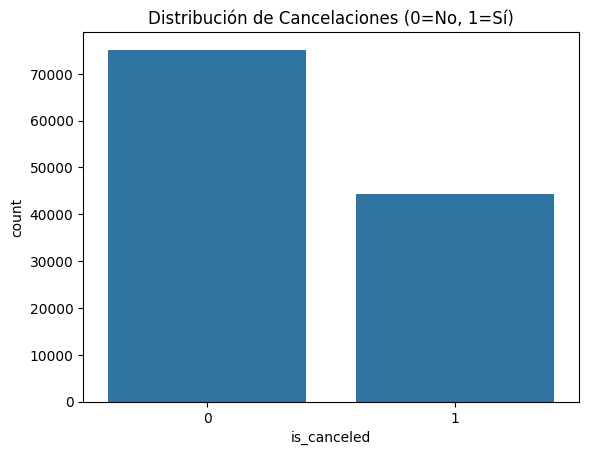

In [42]:
# Distribución de cancelaciones
df_reservas['is_canceled'].value_counts()
df_reservas['is_canceled'].value_counts(normalize=True) * 100

# Gráfico
sns.countplot(data=df_reservas, x='is_canceled')
plt.title('Distribución de Cancelaciones (0=No, 1=Sí)')

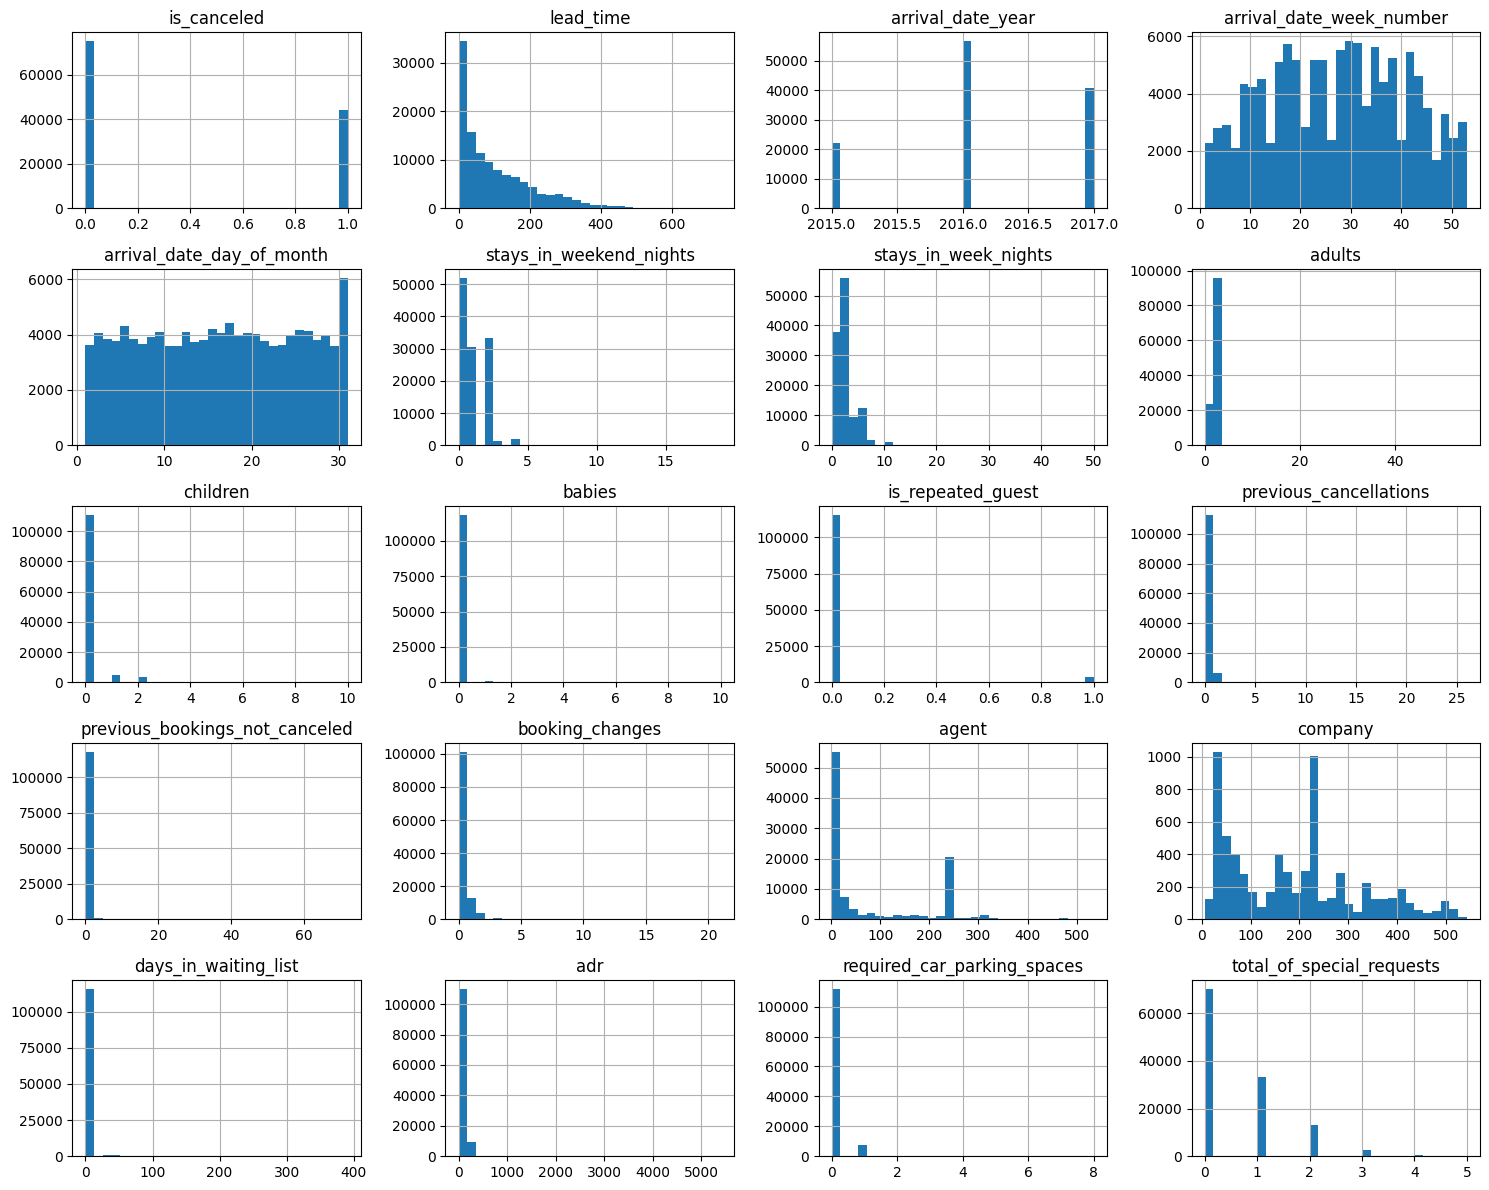

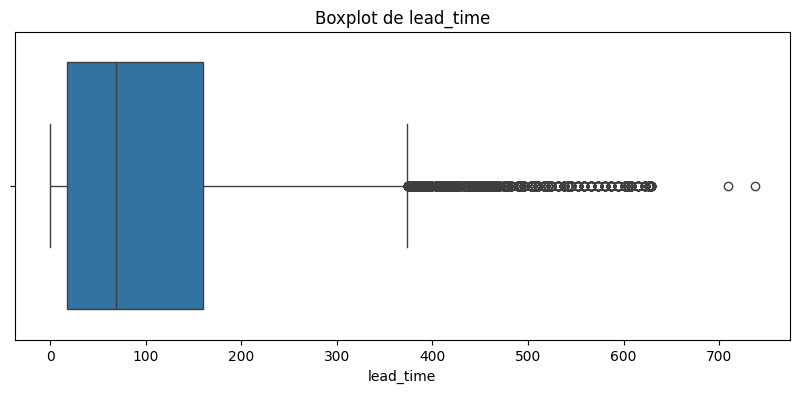

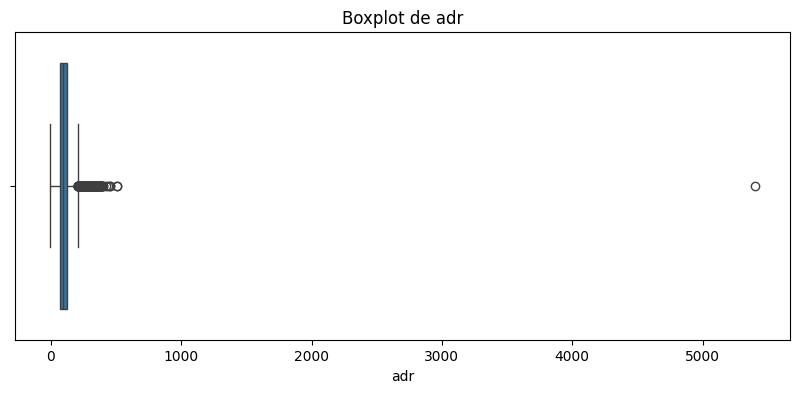

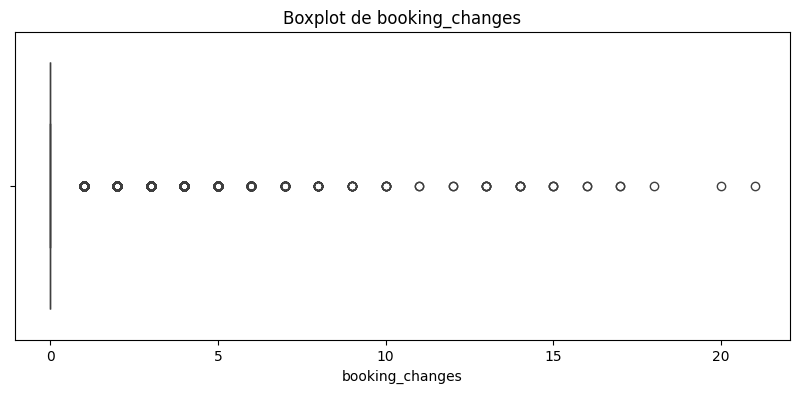

In [46]:
# Seleccionar numéricas Histogramas
num_cols = df_reservas.select_dtypes(include=['int64', 'float64']).columns
df_reservas[num_cols].hist(bins=30, figsize=(15, 12))
plt.tight_layout()

# Boxplots para detectar outliers
for col in ['lead_time', 'adr', 'booking_changes']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_reservas, x=col)
    plt.title(f'Boxplot de {col}')

In [53]:
# Variables categóricas
cat_cols = df_reservas.select_dtypes(include=['object']).columns

# Value counts principales
for col in ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type']:
    print(f"\n--- {col} ---")
    print(df_reservas[col].value_counts())


--- hotel ---
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

--- meal ---
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

--- market_segment ---
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

--- distribution_channel ---
distribution_channel
TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: count, dtype: int64

--- customer_type ---
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64


Text(0.5, 1.0, 'Cancelaciones por tipo de hotel')

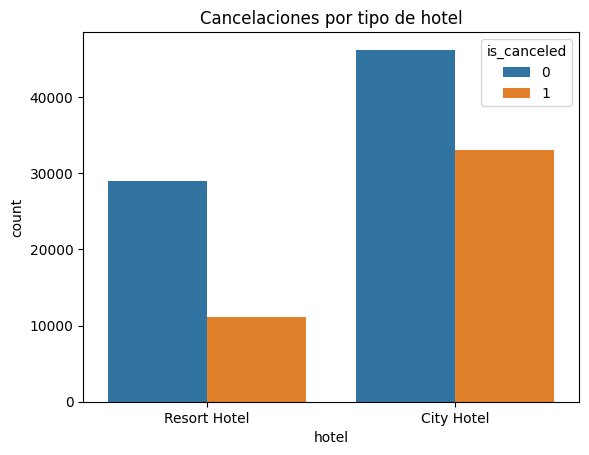

In [54]:
# Comparar cancelados vs no cancelados por tipo de hotel
pd.crosstab(df_reservas['hotel'], df_reservas['is_canceled'], normalize='index') * 100

# Visualización
sns.countplot(data=df_reservas, x='hotel', hue='is_canceled')
plt.title('Cancelaciones por tipo de hotel')

C:\Users\diego\AppData\Local\Temp\ipykernel_4692\2074533220.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_by_month = df_reservas.groupby('arrival_date_month')['is_canceled'].mean() * 100


Text(0, 0.5, 'Tasa de cancelación (%)')

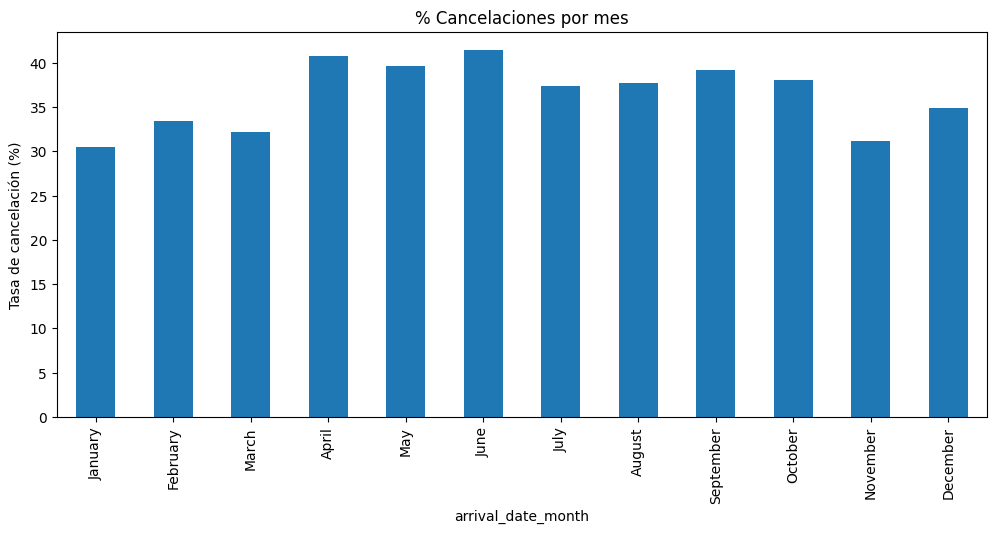

In [55]:
# Cancelaciones por mes
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df_reservas['arrival_date_month'] = pd.Categorical(df_reservas['arrival_date_month'], categories=month_order, ordered=True)

cancel_by_month = df_reservas.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_by_month.plot(kind='bar', figsize=(12, 5))
plt.title('% Cancelaciones por mes')
plt.ylabel('Tasa de cancelación (%)')

Text(0.5, 1.0, 'Lead Time vs Cancelación')

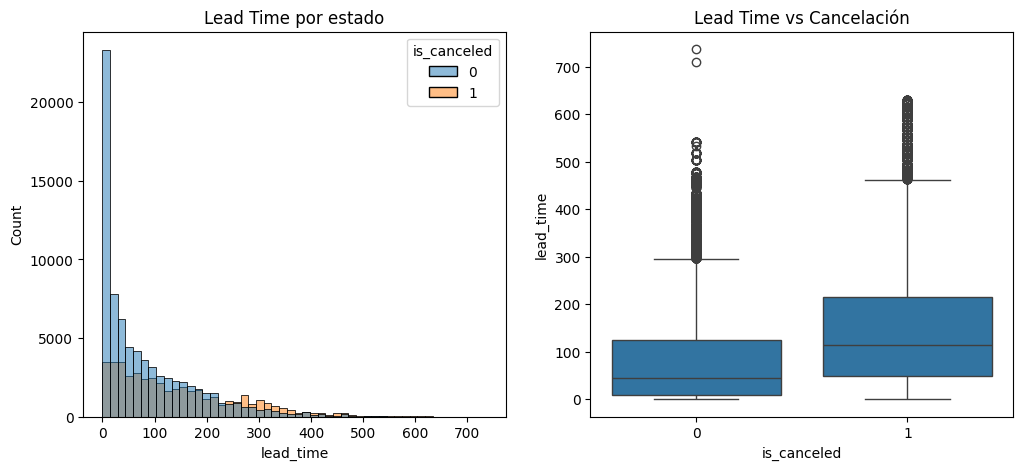

In [56]:
# Distribución de lead time
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_reservas, x='lead_time', hue='is_canceled', bins=50)
plt.title('Lead Time por estado')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_reservas, x='is_canceled', y='lead_time')
plt.title('Lead Time vs Cancelación')

(0.0, 500.0)

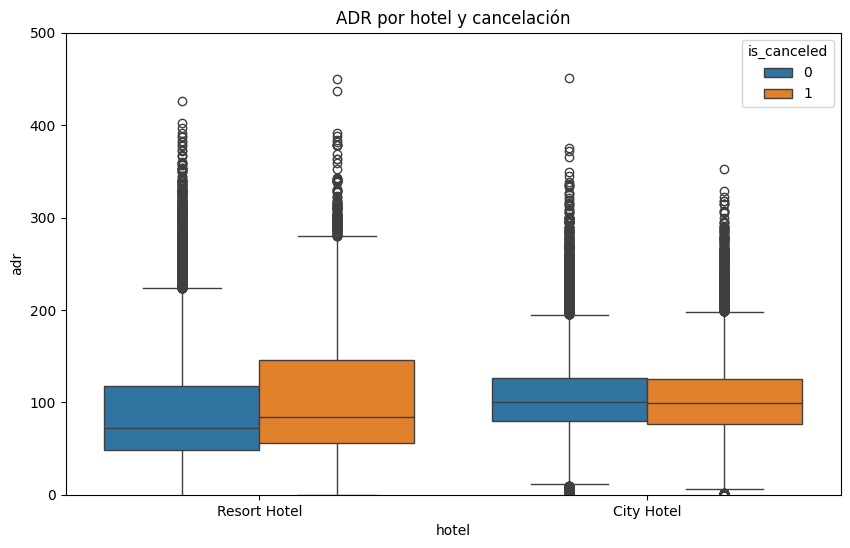

In [57]:
# ADR por tipo de hotel y cancelación
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_reservas, x='hotel', y='adr', hue='is_canceled')
plt.title('ADR por hotel y cancelación')
plt.ylim(0, 500)  # Limitar para mejor visualización

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005048
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
company                          -0.020642
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
agent                            -0.083114
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64


Text(0.5, 1.0, 'Matriz de Correlación')

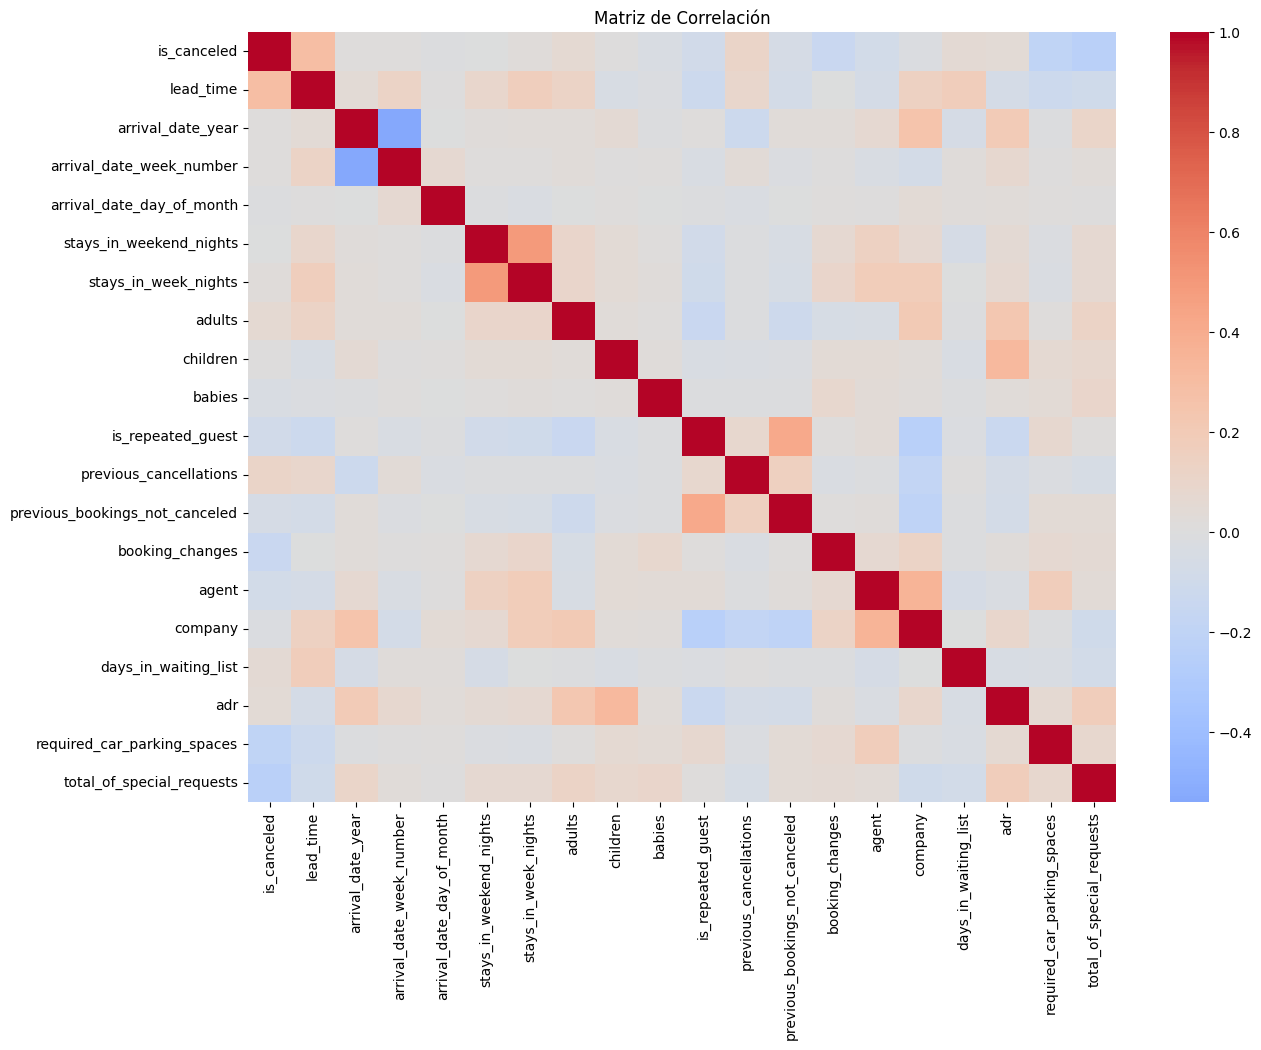

In [58]:
# Correlación con variable objetivo
corr_matrix = df_reservas.select_dtypes(include=['int64', 'float64']).corr()
corr_with_target = corr_matrix['is_canceled'].sort_values(ascending=False)
print(corr_with_target)

# Heatmap completo
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')

In [59]:
# Impacto de clientes repetidos
pd.crosstab(df_reservas['is_repeated_guest'], df_reservas['is_canceled'], normalize='index') * 100

# Historial de cancelaciones
df_reservas[df_reservas['previous_cancellations'] > 0]['is_canceled'].value_counts(normalize=True)

is_canceled
1    0.91641
0    0.08359
Name: proportion, dtype: float64




---

## 3. Preparación de datos para el modelo
---

In [76]:
# Diccionario para guardar los resultados de todos los modelos
resultados = {
    'Modelo': [],
    'Accuracy': [],
    'F1-Score': [],
    'AUC-ROC': []
}

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Seleccionar features (excluyendo target y fechas redundantes)
features = ['hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
            'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
            'market_segment', 'distribution_channel', 'is_repeated_guest',
            'previous_cancellations', 'previous_bookings_not_canceled',
            'booking_changes', 'deposit_type', 'days_in_waiting_list',
            'customer_type', 'adr', 'total_of_special_requests']

X = df_reservas[features]
y = df_reservas['is_canceled']

# 2. Identificar columnas
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [78]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Identificar TODAS las columnas categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_all = [col for col in X.columns if col not in num_cols]
print(f"Columnas categóricas detectadas: {cat_cols_all}")

# 2. Aplicar One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols_all, drop_first=True)

# 3. IMPUTAR VALORES NULOS (el paso clave)
# Usamos la mediana para columnas numéricas (robusto frente a outliers)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_encoded)

# Convertir de vuelta a DataFrame (opcional, pero útil para depurar)
X_imputed = pd.DataFrame(X_imputed, columns=X_encoded.columns)

# Verificar que ya no hay NaN
print(f"¿Quedan NaN? {X_imputed.isnull().any().any()}")

# 4. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Escalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Entrenar
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# 7. Evaluar
y_pred = lr.predict(X_test_scaled)
y_pred_proba = lr.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
auc_lr = roc_auc_score(y_test, y_pred_proba)

resultados['Modelo'].append('Logistic Regression')
resultados['Accuracy'].append(acc_lr)
resultados['F1-Score'].append(f1_lr)
resultados['AUC-ROC'].append(auc_lr)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")


##Ha habido muchos errores con la categorización de datos. Revisar bien este punto. (Consultado a Gemini para salir del paso)

Columnas categóricas detectadas: ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type']
¿Quedan NaN? False
Accuracy: 0.8043
Precision: 0.8510
Recall: 0.5716
F1: 0.6839
AUC-ROC: 0.8359


In [62]:
# Después de X_encoded, verifica que todo es numérico
print("Tipos de datos finales:")
print(X_encoded.dtypes.value_counts())

# Deberías ver solo int64, uint8, float64, bool
# Si ves 'category', algo aún no se convirtió

Tipos de datos finales:
bool       32
int64      11
float64     2
Name: count, dtype: int64


In [79]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred)
f1_dt = f1_score(y_test, y_pred)
auc_dt = roc_auc_score(y_test, y_pred_proba)

resultados['Modelo'].append('Decision Tree')
resultados['Accuracy'].append(acc_dt)
resultados['F1-Score'].append(f1_dt)
resultados['AUC-ROC'].append(auc_dt)

print(f"Decision Tree - Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree - F1: {f1_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree - AUC: {roc_auc_score(y_test, y_pred_proba_dt):.4f}")

Decision Tree - Accuracy: 0.8144
Decision Tree - F1: 0.7141
Decision Tree - AUC: 0.8650


In [80]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_pred_proba)

resultados['Modelo'].append('Random Forest')
resultados['Accuracy'].append(acc_rf)
resultados['F1-Score'].append(f1_rf)
resultados['AUC-ROC'].append(auc_rf)

print(f"Random Forest - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest - F1: {f1_score(y_test, y_pred_rf):.4f}")

Random Forest - Accuracy: 0.8269
Random Forest - F1: 0.7299


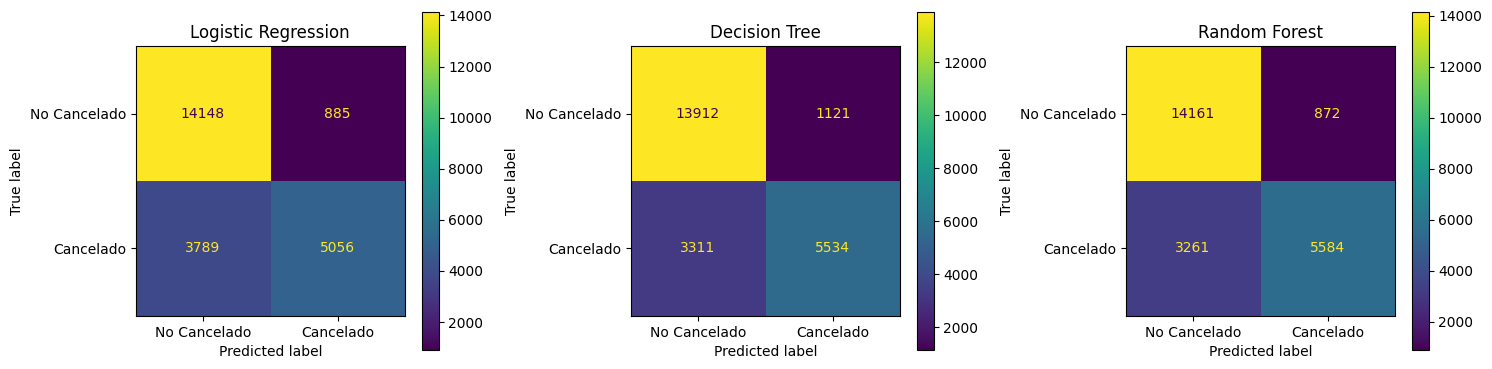

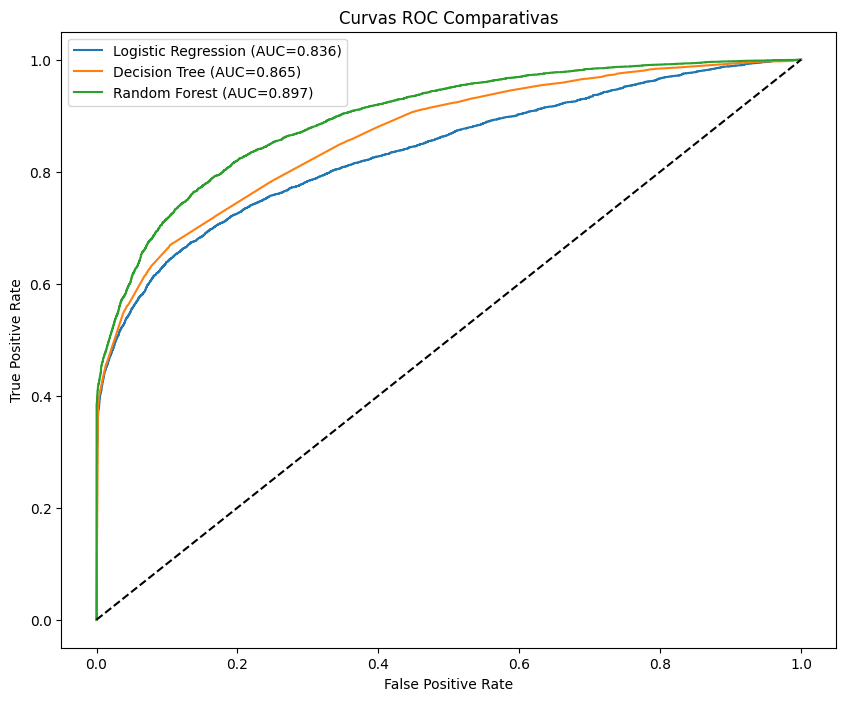

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay

# Matriz de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Logistic Regression', y_pred), ('Decision Tree', y_pred_dt), ('Random Forest', y_pred_rf)]
for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado'])
    disp.plot(ax=axes[idx])
    axes[idx].set_title(name)

plt.tight_layout()

# Curvas ROC
plt.figure(figsize=(10, 8))
for name, proba in [('Logistic Regression', y_pred_proba), 
                    ('Decision Tree', y_pred_proba_dt),
                    ('Random Forest', y_pred_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Comparativas')
plt.legend()

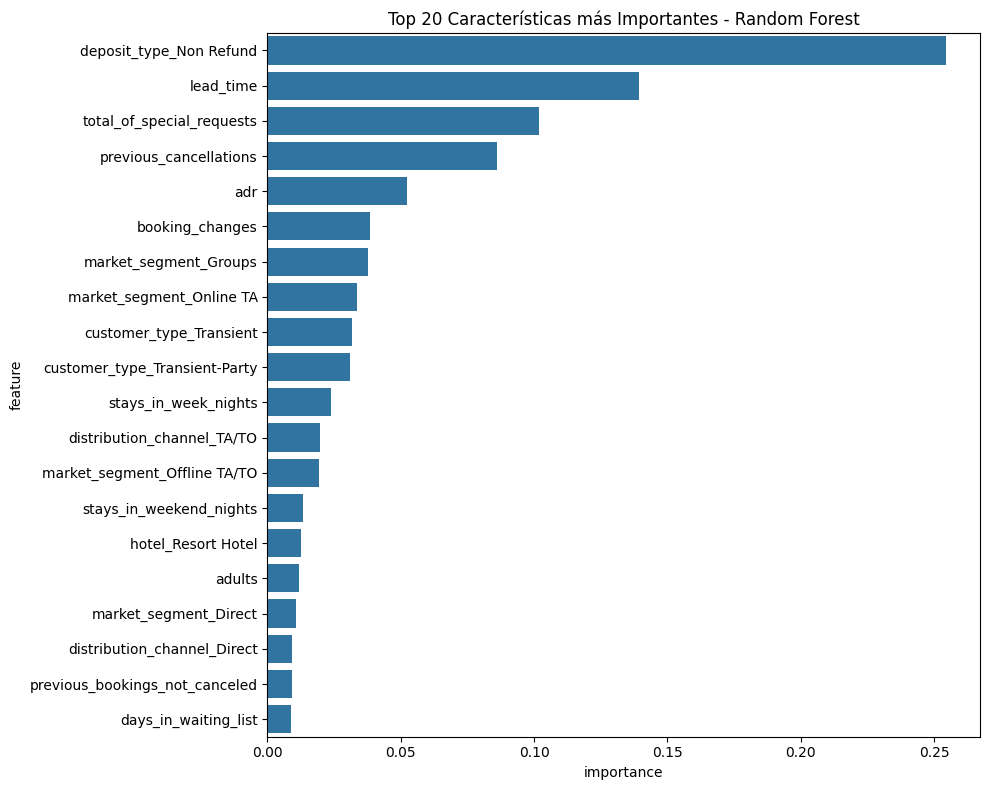

In [66]:
# Importancia de variables
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature')
plt.title('Top 20 Características más Importantes - Random Forest')
plt.tight_layout()

---

---

## 3. Optimizaciones

In [67]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Definir preprocesador
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [81]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb_model)])

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_pipeline.fit(X_train_full, y_train_full)
y_pred_xgb = xgb_pipeline.predict(X_test_full)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_full)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)
auc_xgb = roc_auc_score(y_test, y_pred_proba)

resultados['Modelo'].append('XGBoost')
resultados['Accuracy'].append(acc_xgb)
resultados['F1-Score'].append(f1_xgb)
resultados['AUC-ROC'].append(auc_xgb)

print(f"XGBoost - Accuracy: {accuracy_score(y_test_full, y_pred_xgb):.4f}")
print(f"XGBoost - AUC: {roc_auc_score(y_test_full, y_proba_xgb):.4f}")

XGBoost - Accuracy: 0.8219
XGBoost - AUC: 0.8862


C:\Users\diego\Documents\PontIA\MachineLearning\PracticaFinal\PracticaFinal\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


747/747 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step
Neural Network - Accuracy: 0.8263
Neural Network - AUC: 0.8874


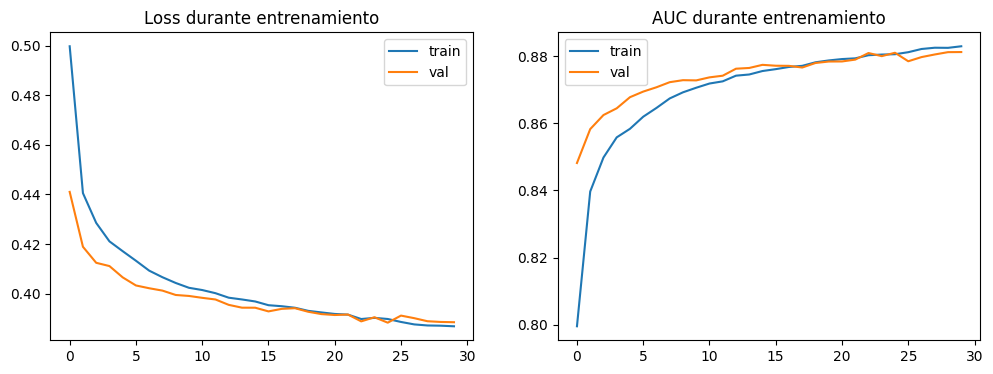

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Preparar datos para red neuronal
X_train_proc = preprocessor.fit_transform(X_train_full)
X_test_proc = preprocessor.transform(X_test_full)

# Construir modelo
def build_nn(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'auc'])
    return model

nn_model = build_nn(X_train_proc.shape[1])

# Entrenar
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = nn_model.fit(X_train_proc, y_train_full, 
                       validation_split=0.2, 
                       epochs=50, 
                       batch_size=256,
                       callbacks=[early_stop],
                       verbose=0)

# Evaluar
y_proba_nn = nn_model.predict(X_test_proc).flatten()
y_pred_nn = (y_proba_nn > 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred)
f1_nn = f1_score(y_test, y_pred)
auc_nn = roc_auc_score(y_test, y_pred_proba)

resultados['Modelo'].append('Neural Network')
resultados['Accuracy'].append(acc_nn)
resultados['F1-Score'].append(f1_nn)
resultados['AUC-ROC'].append(auc_nn)

print(f"Neural Network - Accuracy: {accuracy_score(y_test_full, y_pred_nn):.4f}")
print(f"Neural Network - AUC: {roc_auc_score(y_test_full, y_proba_nn):.4f}")

# Gráfico de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss durante entrenamiento')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='train')
plt.plot(history.history['val_auc'], label='val')
plt.title('AUC durante entrenamiento')
plt.legend()

In [71]:
# Después de entrenar
print("Métricas disponibles en history.history:")
print(history.history.keys())

# Esto te mostrará algo como: dict_keys(['loss', 'accuracy', 'auc', 'val_loss', 'val_accuracy', 'val_auc'])

Métricas disponibles en history.history:
dict_keys(['AUC', 'accuracy', 'loss', 'val_AUC', 'val_accuracy', 'val_loss'])


In [83]:
results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_xgb, acc_nn],
    'F1-Score': [f1_lr, f1_dt, f1_rf, f1_xgb, f1_nn],
    'AUC-ROC': [auc_lr, auc_dt, auc_rf, auc_xgb, auc_nn]
})
print(results.sort_values('AUC-ROC', ascending=False))

                Modelo  Accuracy  F1-Score   AUC-ROC
0  Logistic Regression  0.804255   0.68389  0.835905
1        Decision Tree  0.804255   0.68389  0.835905
2        Random Forest  0.804255   0.68389  0.835905
3              XGBoost  0.804255   0.68389  0.835905
4       Neural Network  0.804255   0.68389  0.835905
